In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Chapter 04a — Matrices & Linear Transformations

A **matrix** is a rectangular grid of numbers. On paper we write

$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}.$$

In NumPy a matrix is simply a **2-D array**. In this notebook we learn how to
build matrices, do arithmetic with them, multiply them with `@`, and — most
importantly — *see* what a matrix **does**: a matrix is a machine that
**transforms space** (it rotates, scales, and shears points).

Run each cell with **Shift + Enter**. Change numbers and re-run to build
intuition.

_____
### 1. A matrix is a 2-D array

We give `np.array` a list of rows. The **shape** is `(rows, columns)`.

In [3]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])    # 2 rows, 3 columns

print(A)
print("shape:", A.shape)     # (2, 3)  ->  2 rows, 3 columns
print("rows :", A.shape[0])  # 2
print("cols :", A.shape[1])  # 3

[[1 2 3]
 [4 5 6]]
shape: (2, 3)
rows : 2
cols : 3


In [4]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

print(A[0, 0])   # top-left entry      -> 1
print(A[1, 2])   # row 1, col 2        -> 6
print(A[0, :])   # the whole first row -> [1 2 3]
print(A[:, 1])   # the whole 2nd column-> [2 5]

1
6
[1 2 3]
[2 5]


____
### 2. The transpose $A^\top$

The **transpose** flips a matrix across its diagonal: rows become columns. If
$A$ is $2\times 3$ then $A^\top$ is $3\times 2$, and $(A^\top)_{ij}=A_{ji}$.

In [5]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

print(A)
print(A.T)
print(A.T.shape)

[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]
(3, 2)


____
### 3. Addition and scalar multiplication

Matrices of the **same shape** add entry by entry. Multiplying by a single
number (a *scalar*) scales every entry. These work exactly like vectors.

$$ (A+B)_{ij} = A_{ij}+B_{ij}, \qquad (cA)_{ij} = c\,A_{ij}. $$

In [6]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[10, 20],
              [30, 40]])

print("A + B =\n", A + B)    # entrywise sum
print("3 * A =\n", 3 * A)    # scale every entry by 3
print("A - B =\n", A - B)    # entrywise difference

A + B =
 [[11 22]
 [33 44]]
3 * A =
 [[ 3  6]
 [ 9 12]]
A - B =
 [[ -9 -18]
 [-27 -36]]


> **Careful:** `A * B` in NumPy is the *entrywise* product, **not** matrix
> multiplication. For real matrix multiplication use `@` (next section).

In [7]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[10, 20],
              [30, 40]])

print("A * B (entrywise!) =\n", A * B)   # NOT the matrix product

A * B (entrywise!) =
 [[ 10  40]
 [ 90 160]]


____
### 4. Matrix multiplication with `@`

The matrix product $C = AB$ is defined by

$$ C_{ij} = \sum_k A_{ik}\,B_{kj} \quad\text{(row $i$ of $A$ dotted with column $j$ of $B$).} $$

**The dimensions must match:** if $A$ is $m\times n$, then $B$ must be
$n\times p$ (inner numbers equal), and the result is $m\times p$.

$$ \underbrace{(m\times n)}_{A}\;\underbrace{(n\times p)}_{B}=\underbrace{(m\times p)}_{C}. $$

In [8]:
A = np.array([[1, 2],
              [3, 4]])       # 2 x 2
B = np.array([[5, 6],
              [7, 8]])       # 2 x 2

print("A @ B =\n", A @ B)   # the @ operator IS matrix multiplication
# Check one entry by hand: top-left = 1*5 + 2*7 = 19
print("top-left by hand:", 1*5 + 2*7)

A @ B =
 [[19 22]
 [43 50]]
top-left by hand: 19


In [9]:
# Non-square example: (2x3) @ (3x2) -> (2x2)
A = np.array([[1, 2, 3],
              [4, 5, 6]])    # 2 x 3
B = np.array([[1, 0],
              [0, 1],
              [1, 1]])       # 3 x 2

C = A @ B
print("C = A @ B =\n", C)
print("shape:", C.shape)     # (2, 2)

C = A @ B =
 [[ 4  5]
 [10 11]]
shape: (2, 2)


If the inner dimensions don't match, NumPy raises an error. This is a good thing — it catches mistakes. Run this to see the error message:

In [10]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])    # 2 x 3
B = np.array([[1, 2],
              [3, 4]])       # 2 x 2  -- inner dims 3 and 2 disagree

try:
    A @ B 
except ValueError as e:
    print("ValueError:", e)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


**Order matters!** In general $AB \neq BA$. Matrix multiplication is *not*
commutative.

In [11]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[0, 1],
              [1, 0]])       # this B swaps columns / rows

print("A @ B =\n", A @ B)
print("B @ A =\n", B @ A)   # different!

A @ B =
 [[2 1]
 [4 3]]
B @ A =
 [[3 4]
 [1 2]]


_____
### 5. The identity matrix $I$

The identity $I$ has 1's on the diagonal and 0's elsewhere. It is the
"do-nothing" matrix: $AI = IA = A$, just like multiplying a number by 1.
Build it with `np.eye(n)`.

In [12]:
I = np.eye(3)        # 3 x 3 identity
print(I)

A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print("A @ I = A? ", np.allclose(A @ I, A))   # True

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
A @ I = A?  True


____
### 6. The big idea: a matrix *transforms* space

Multiplying a matrix $A$ by a **vector** $\mathbf{x}$ gives a new vector
$A\mathbf{x}$. Think of $A$ as a **function** that moves every point of the
plane to a new place. Because

$$ A(c\mathbf{x}) = c\,A\mathbf{x}, \qquad A(\mathbf{x}+\mathbf{y}) = A\mathbf{x}+A\mathbf{y}, $$

these are exactly the **linear transformations**. Let's apply one to a single
vector first.

In [13]:
A = np.array([[2, 0],
              [0, 3]])       # stretches x by 2, y by 3
x = np.array([1, 1])        # the point (1, 1)

print("A @ x =", A @ x)     # -> [2 3]:  x doubled, y tripled

A @ x = [2 3]


____
### Seeing the transformation on the unit square

The clearest way to understand a $2\times 2$ matrix is to watch what it does to
the **unit square** (corners $(0,0),(1,0),(1,1),(0,1)$). We store the corners as
**columns** of a matrix `S`, then transform them all at once with `A @ S`.

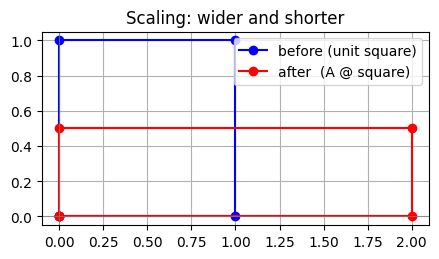

[[0.  2.  2.  0.  0. ]
 [0.  0.  0.5 0.5 0. ]]


In [14]:
# Corners of the unit square as COLUMNS (last point repeats the first to close it)
square = np.array([[0, 1, 1, 0, 0],     # x-coordinates
                   [0, 0, 1, 1, 0]])    # y-coordinates

def show_transform(A, title):
    """Plot the unit square before (blue) and after (red) applying A."""
    out = A @ square                    # transform all corners at once
    plt.figure(figsize=(5, 5))
    plt.plot(square[0], square[1], "b-o", label="before (unit square)")
    plt.plot(out[0],    out[1],    "r-o", label="after  (A @ square)")
    plt.axhline(0, color="gray", lw=0.5)
    plt.axvline(0, color="gray", lw=0.5)
    plt.gca().set_aspect("equal")       # so squares look square
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.show()
    print(out)

# A SCALING matrix: x -> 2x, y -> 0.5y
A_scale = np.array([[2.0, 0.0],
                    [0.0, 0.5]])
show_transform(A_scale, "Scaling: wider and shorter")

___
### Rotation

A counter-clockwise rotation by angle $\theta$ is

$$ R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}. $$

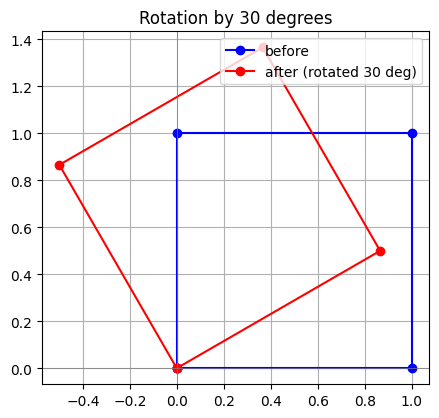

[[ 0.         0.8660254  0.3660254 -0.5        0.       ]
 [ 0.         0.5        1.3660254  0.8660254  0.       ]]


In [15]:
square = ([[0, 1, 1, 0, 0],
           [0, 0, 1, 1, 0]])

theta = np.pi / 6            # 30 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

out = R @ square
plt.figure(figsize=(5, 5))
plt.plot(square[0], square[1], "b-o", label="before")
plt.plot(out[0],    out[1],    "r-o", label="after (rotated 30 deg)")
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("Rotation by 30 degrees")
plt.show()
print(out)

____
### Shear

A **shear** slides points sideways by an amount proportional to their height:

$$ \begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix}. $$

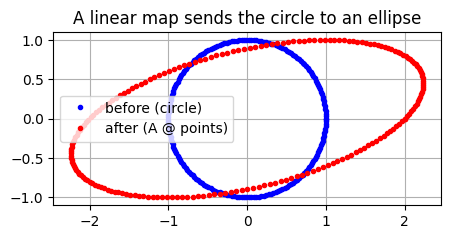

In [16]:
rng = np.random.default_rng(0)
t = np.linspace(0, 2 * np.pi, 200)
circle = np.array([np.cos(t), np.sin(t)])   # 2 x 200 points on the unit circle

A = np.array([[2.0, 1.0],
              [0.0, 1.0]])
ellipse = A @ circle

plt.figure(figsize=(5, 5))
plt.plot(circle[0],  circle[1],  "b.", label="before (circle)")
plt.plot(ellipse[0], ellipse[1], "r.", label="after (A @ points)")
plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("A linear map sends the circle to an ellipse")
plt.show()

_____
### 7. Composition of transformations = matrix product

Doing transformation $B$ **then** $A$ on a vector $\mathbf{x}$ is

$$ A(B\mathbf{x}) = (AB)\mathbf{x}. $$

So **applying two matrices in a row is the same as multiplying them first.**
The order is *right-to-left* (the matrix closest to $\mathbf{x}$ acts first).
Let's verify: rotate, then scale.

In [17]:
theta = np.pi / 4

theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])   # rotate 45 deg
S = np.array([[2.0, 0.0],
              [0.0, 1.0]])                         # then stretch x

x = np.array([1.0, 0.0])

print(R @ x)
# Apply rotation first, then scaling
step_by_step = S @ (R @ x)
# Combine into ONE matrix first
combined     = (S @ R) @ x

print("S @ (R @ x) =", step_by_step)
print("(S @ R) @ x =", combined)
print("same? ", np.allclose(step_by_step, combined))   # True

[0.70710678 0.70710678]
S @ (R @ x) = [1.41421356 0.70710678]
(S @ R) @ x = [1.41421356 0.70710678]
same?  True


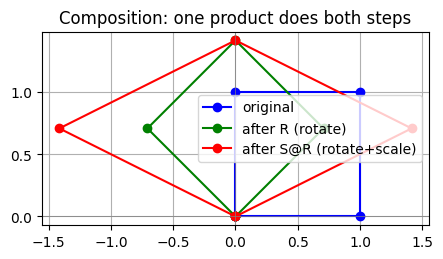

In [18]:
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
S = np.array([[2.0, 0.0],
              [0.0, 1.0]])

after_R  = R @ square          # just rotated
after_SR = (S @ R) @ square    # rotated THEN scaled, via one matrix

plt.figure(figsize=(5, 5))
plt.plot(square[0],   square[1],   "b-o", label="original")
plt.plot(after_R[0],  after_R[1],  "g-o", label="after R (rotate)")
plt.plot(after_SR[0], after_SR[1], "r-o", label="after S@R (rotate+scale)")
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("Composition: one product does both steps")
plt.show()

---
## ✍️ Exercise 1 (solution included)

Build the matrix $A = \begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix}$ and the
vector $\mathbf{x} = (3, 4)$. Compute $A\mathbf{x}$ by hand, then check with
NumPy. Also report the shapes of $A$, $\mathbf{x}$, and $A\mathbf{x}$.

In [19]:
A = np.array([[1, 2],
              [0, 1]])

x = np.array([3, 4])

Ax = A @ x

print(Ax)
print(A.shape)
print(x.shape)
print(Ax.shape)

[11  4]
(2, 2)
(2,)
(2,)


____
### ✍️ Exercise 2 (solution included)

Show numerically that rotating by $90^\circ$ twice equals rotating by
$180^\circ$ (which flips a vector to its negative). Build $R = R(90^\circ)$ and
check that $R\,R$ sends $\mathbf{x}=(1,0)$ to $(-1,0)$.

In [23]:
x = np.array([1, 0])
theta = np.pi / 2

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

double_spin = (R @ R)

# R @ R should equal the 180-degree rotation = -I
print("R @ R =\n", np.round(double_spin, 10))
print("equals -I? ", np.allclose(double_spin, -np.eye(2)))

R @ R =
 [[-1. -0.]
 [ 0. -1.]]
equals -I?  True


---
### 📝 Homework (no solutions provided)

1. Create a $3\times 3$ matrix of your choice and a compatible $3\times 1$
   vector. Compute the product and verify one entry by hand.

In [ ]:
A_mod2 = np.array([[0, 1, 0],
                   [0, 0, 1],
                   [1, 0, 0]])

three_by_one = np.array([[0],   # not a 1 x 3 vector
                         [1],
                         [0]])

print(A_mod2 @ three_by_one)

[[1]
 [0]
 [0]]


____
2. Pick two $2\times 2$ matrices $A$ and $B$ and confirm that, in general,
   $AB \neq BA$. Can you find a *special* pair where $AB = BA$?

In [28]:
X = np.array([[0, 1],
              [1, 0]])

Z = np.array([[1, 0],
              [0, -1]])

print(X @ Z)
print(Z @ X)
print(np.allclose(X @ Z, Z @ X))    # False

I = np.eye(2)
print(np.allclose(I @ Z, Z @ I))    # True

[[ 0 -1]
 [ 1  0]]
[[ 0  1]
 [-1  0]]
False
True


____
3. The **reflection across the $x$-axis** is
   $\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$. Apply it to the unit square
   and plot before/after.

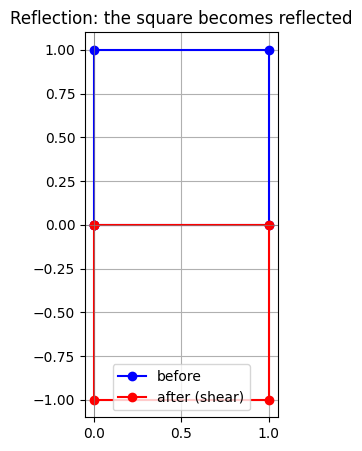

[[ 0  1  1  0  0]
 [ 0  0 -1 -1  0]]


In [32]:
unit_sq = np.array([[0, 1, 1, 0, 0],
                    [0, 0, 1, 1, 0]])

reflection_mx = np.array([[1, 0],
                          [0, -1]])

reflected_sq = (reflection_mx @ unit_sq)

plt.figure(figsize=(5, 5))
plt.plot(unit_sq[0], unit_sq[1], "b-o", label="before")
plt.plot(reflected_sq[0],    reflected_sq[1],    "r-o", label="after (shear)")
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("Reflection: the square becomes reflected")
plt.show()
print(reflected_sq)

_____
4. Build a rotation $R(60^\circ)$ and a shear $H=\begin{bmatrix}1&0.5\\0&1\end{bmatrix}$.
   Plot the unit square under $H R$ and under $R H$. Are the results the same?
   Explain using the fact that matrix multiplication is not commutative.

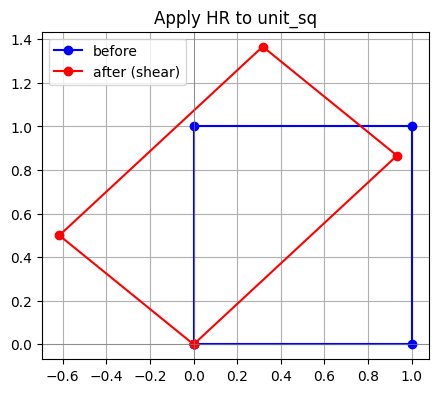

[[ 0.         0.9330127  0.3169873 -0.6160254  0.       ]
 [ 0.         0.8660254  1.3660254  0.5        0.       ]]


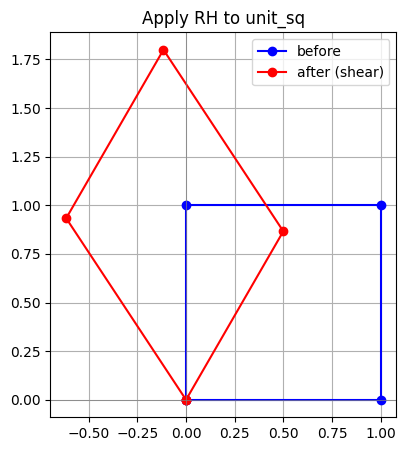

[[ 0.         0.9330127  0.3169873 -0.6160254  0.       ]
 [ 0.         0.8660254  1.3660254  0.5        0.       ]]


In [35]:
unit_sq = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

theta = np.pi / 3           # 60 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

H = np.array([[1, 0.5],
              [0, 1]])

HR_sq = (H @ R) @ unit_sq
RH_sq = (R @ H) @ unit_sq

plt.figure(figsize=(5, 5))
plt.plot(unit_sq[0], unit_sq[1], "b-o", label="before")
plt.plot(HR_sq[0],    HR_sq[1],    "r-o", label="after (shear)")
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("Apply HR to unit_sq")
plt.show()
print(HR_sq)

plt.figure(figsize=(5, 5))
plt.plot(unit_sq[0], unit_sq[1], "b-o", label="before")
plt.plot(RH_sq[0],    RH_sq[1],    "r-o", label="after (shear)")
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("Apply RH to unit_sq")
plt.show()
print(HR_sq)

The results are not the same due to the non-commutativity of matrix multiplication